# Loan Default Prediction using SBA Loan Data

## Overview
Predict whether a Small Business Administration loan will default.
The models used in this project are Logistic Regression and Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Cleaning

In [20]:
#Loading SBA loan data
data= pd.read_csv("SBAnational.csv")

#Check
print(data.shape)
data.head()

#Looking for missing values
miss= data.isnull().sum()
miss= miss[miss > 0].sort_values(ascending=False)
print(miss)

#Removing duplicates
data=data.drop_duplicates()
print(data.shape)

#Removing observations that have missing loan entries
data= data.dropna(subset=["MIS_Status"])
print(data.shape)

#Categorical variables
print(data["RevLineCr"].value_counts(dropna=False))
print(data["LowDoc"].value_counts(dropna=False))
print(data["NewExist"].value_counts(dropna=False))
print(data["UrbanRural"].value_counts(dropna=False))
print(data["FranchiseCode"].value_counts(dropna=False))

#Create the target
data["default"] = (data["MIS_Status"] == "CHGOFF").astype(int)

print(data["MIS_Status"].value_counts())
print(data["default"].value_counts())

#Cleaning the categorical values
data["RevLineCr"] = data["RevLineCr"].replace({
    "0":"N","1":"Y",
    "T":np.nan, "`":np.nan, ",":np.nan})

data["LowDoc"] = data["LowDoc"].replace("C",np.nan)
data["NewExist"] = data["NewExist"].replace(0,np.nan)

print(data["RevLineCr"].value_counts(dropna=False))
print(data["LowDoc"].value_counts(dropna=False))
print(data["NewExist"].value_counts(dropna=False))

money = ["DisbursementGross","BalanceGross","ChgOffPrinGr",
         "GrAppv","SBA_Appv"]
for col in money:
    data[col] = (data[col]
                 .str.replace("$","",regex=False)
                 .str.replace(",","",regex=False)
                 .astype(float))

print(data[money].head())
print(data[money].dtypes)

# Change the date format
data["ApprovalDate"]= pd.to_datetime(data["ApprovalDate"], format="%d-%b-%y")
data["DisbursementDate"]= pd.to_datetime(data["DisbursementDate"],format="%d-%b-%y")
data["ChgOffDate"]= pd.to_datetime(data["ChgOffDate"],format="%d-%b-%y")

print(data[["ApprovalDate","DisbursementDate","ChgOffDate"]].head())
print(data.info())

(83015, 27)
ChgOffDate           62355
MIS_Status             658
DisbursementDate       116
Bank                    88
BankState               88
RevLineCr               12
Name                     6
State                    2
City                     1
LowDoc                   1
UrbanRural               1
FranchiseCode            1
DisbursementGross        1
BalanceGross             1
ChgOffPrinGr             1
GrAppv                   1
SBA_Appv                 1
dtype: int64
(83015, 27)
(82357, 27)
RevLineCr
N      41452
Y      26556
0      11538
T       2796
NaN       11
1          2
`          1
,          1
Name: count, dtype: int64
LowDoc
N    75505
Y     6837
C       15
Name: count, dtype: int64
NewExist
1    56530
2    25744
0       83
Name: count, dtype: int64
UrbanRural
1.0    45505
0.0    27095
2.0     9757
Name: count, dtype: int64
FranchiseCode
1.0        55941
0.0        23221
78760.0      203
68020.0       94
50564.0       77
           ...  
30780.0        1
17256.0  

## Exploratory Data Analysis

default
0    62549
1    19808
Name: count, dtype: int64
default
0    75.948614
1    24.051386
Name: proportion, dtype: float64


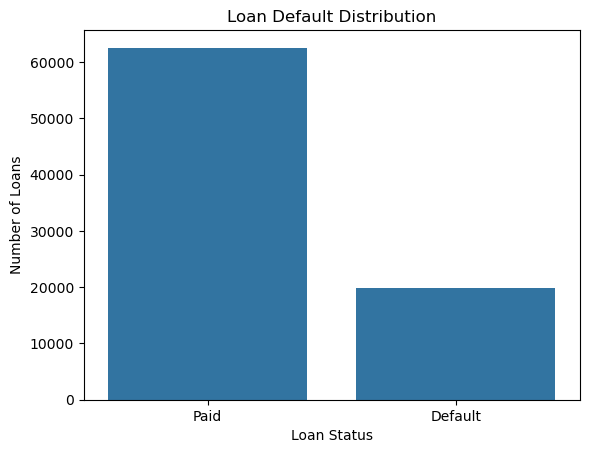

In [3]:
print(data["default"].value_counts())
print(data["default"].value_counts(normalize=True) *100)

sns.countplot(data=data,x="default")

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")

plt.xticks([0,1],["Paid","Default"])
plt.show()

### Numerical Variables

In [4]:
numerical= ["Term","NoEmp","CreateJob","RetainedJob",
            "DisbursementGross","GrAppv","SBA_Appv"]
print(data[numerical].describe().round(2))

           Term     NoEmp  CreateJob  RetainedJob  DisbursementGross  \
count  82357.00  82357.00   82357.00     82357.00           82357.00   
mean      91.18      8.94       1.08         3.42          134443.13   
std       67.51     74.85       5.96        14.41          210803.32   
min        0.00      0.00       0.00         0.00            4000.00   
25%       58.00      2.00       0.00         0.00           30000.00   
50%       84.00      4.00       0.00         1.00           60025.00   
75%       84.00      8.00       0.00         4.00          140000.00   
max      461.00   9999.00    1000.00      3225.00         3599911.00   

           GrAppv    SBA_Appv  
count    82357.00    82357.00  
mean    122211.60    87305.15  
std     205979.34   159711.97  
min       1000.00      500.00  
25%      25000.00    12500.00  
50%      50000.00    25000.00  
75%     100000.00    78800.00  
max    3300000.00  3275000.00  


Some variables seem to be highly skewed. The average loan amount is 134,000 while the median is only at around 60,000. This suggests that a small amount of very large loans increase the average.


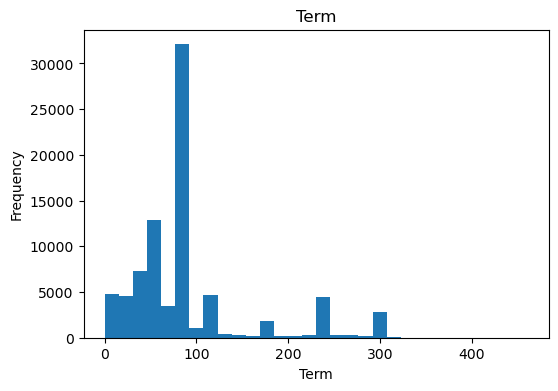

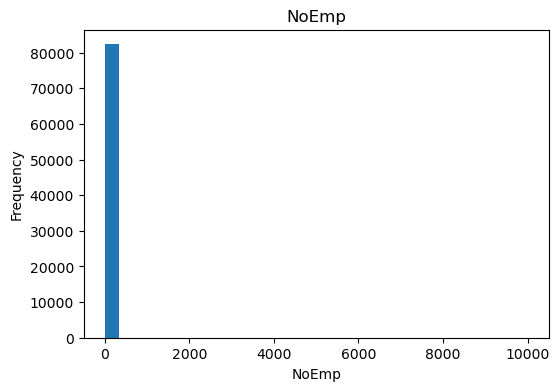

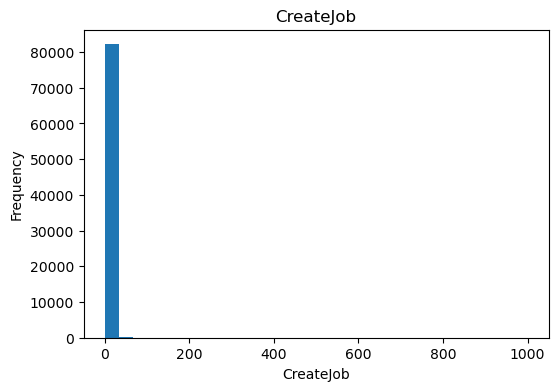

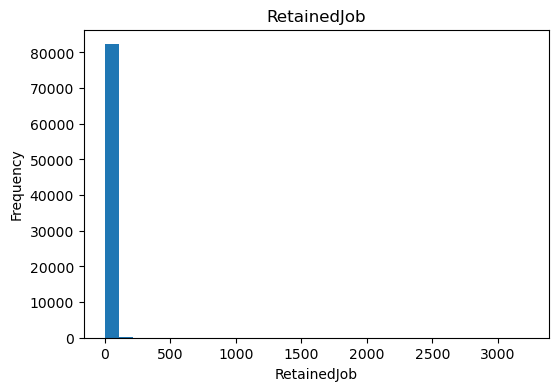

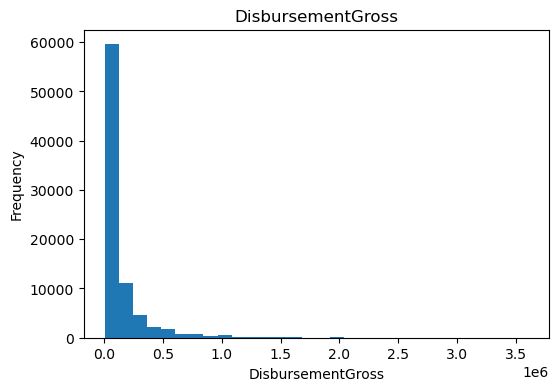

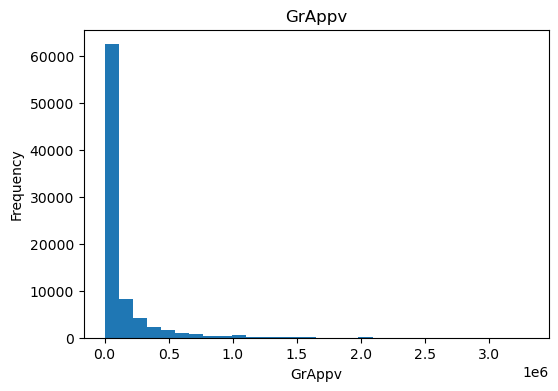

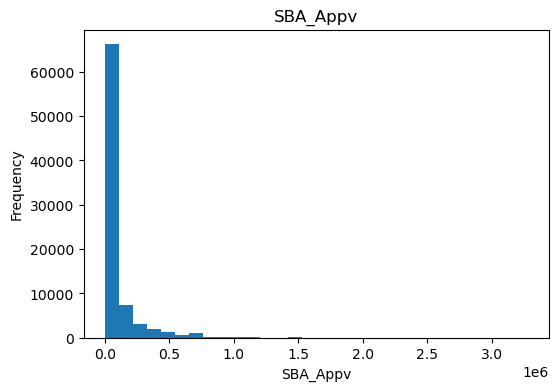

In [5]:
#Numerical variables histogram

for col in numerical:
    plt.figure(figsize=(6,4))
    plt.hist(data[col],bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


## Categorical Variables


 NewExist
default          0         1
NewExist                    
1.0       0.748859  0.251141
2.0       0.782124  0.217876

 RevLineCr
default          0        1
RevLineCr                  
N          0.78060  0.21940
Y          0.75898  0.24102

 LowDoc
default         0         1
LowDoc                     
N        0.743937  0.256063
Y        0.930818  0.069182

 UrbanRural
default            0         1
UrbanRural                    
0.0         0.895737  0.104263
1.0         0.680343  0.319657
2.0         0.750231  0.249769


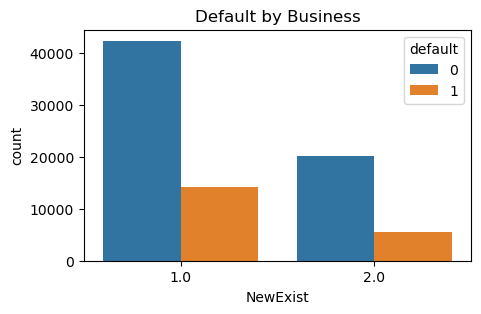

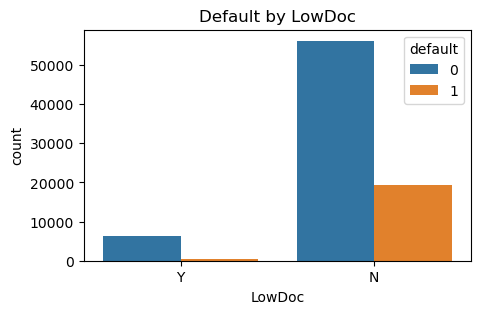

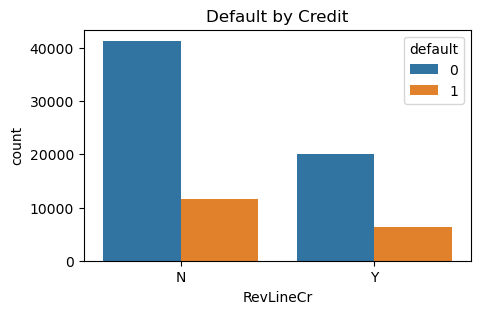

In [6]:
# Default rate by categorical variables
categorical = ["NewExist","RevLineCr","LowDoc","UrbanRural"]
for col in categorical:
    print("\n",col)
    print(pd.crosstab(data[col], data["default"],normalize="index"))

plt.figure(figsize=(5,3))
sns.countplot(data=data,x="NewExist", hue="default")
plt.title("Default by Business")
plt.show()

plt.figure(figsize=(5,3))
sns.countplot(data=data,x="LowDoc", hue="default")
plt.title("Default by LowDoc")
plt.show()

plt.figure(figsize=(5,3))
sns.countplot(data=data,x="RevLineCr", hue="default")
plt.title("Default by Credit")
plt.show()


## Feature Engineering

In [7]:
# Remove variables that are not needed

data= data.drop(columns=["LoanNr_ChkDgt","Name","City","Zip","ChgOffDate","MIS_Status"])

#Make an approval year
data["ApprovalYear"]= data["ApprovalDate"].dt.year
data= data.drop(columns=["ApprovalDate"])

#SBA guarantee percentage
data["Guarantee"]= data["SBA_Appv"]/ data["GrAppv"]

#Only keep 2 digits of the NAICS code
data["NAICS"]= data["NAICS"].astype(str).str[:2]
print(data.head())

  State                           Bank BankState NAICS  ApprovalFY  Term  \
0    IN               FIFTH THIRD BANK        OH    45        1997    84   
1    IN                1ST SOURCE BANK        IN    72        1997    60   
2    IN        GRANT COUNTY STATE BANK        IN    62        1997   180   
3    OK  1ST NATL BK & TR CO OF BROKEN        OK     0        1997    60   
4    FL        FLORIDA BUS. DEVEL CORP        FL     0        1997   240   

   NoEmp  NewExist  CreateJob  RetainedJob  ...  LowDoc  DisbursementDate  \
0      4       2.0          0            0  ...       Y        1999-02-28   
1      2       2.0          0            0  ...       Y        1997-05-31   
2      7       1.0          0            0  ...       N        1997-12-31   
3      2       1.0          0            0  ...       Y        1997-06-30   
4     14       1.0          7            7  ...       N        1997-05-14   

  DisbursementGross BalanceGross ChgOffPrinGr    GrAppv  SBA_Appv  default  \
0 

In [8]:
print(data.isnull().sum())

data= data.drop(columns= ["ApprovalFY","DisbursementDate","ChgOffPrinGr"])
data= data.dropna()

print(data.shape)
print(data.isnull().sum())

State                   1
Bank                   62
BankState              62
NAICS                   0
ApprovalFY              0
Term                    0
NoEmp                   0
NewExist               83
CreateJob               0
RetainedJob             0
FranchiseCode           0
UrbanRural              0
RevLineCr            2809
LowDoc                 15
DisbursementDate       79
DisbursementGross       0
BalanceGross            0
ChgOffPrinGr            0
GrAppv                  0
SBA_Appv                0
default                 0
ApprovalYear            0
Guarantee               0
dtype: int64
(79388, 20)
State                0
Bank                 0
BankState            0
NAICS                0
Term                 0
NoEmp                0
NewExist             0
CreateJob            0
RetainedJob          0
FranchiseCode        0
UrbanRural           0
RevLineCr            0
LowDoc               0
DisbursementGross    0
BalanceGross         0
GrAppv               0
SBA_Appv 

## Preparing the Data

In [9]:
data = data.drop(columns=["Bank"])

x = data.drop(columns="default")
y = data["default"]
print(x.shape)
print(y.shape)

#Converting to dummy variables 
x = pd.get_dummies(x,drop_first=True)
print(x.shape)

(79388, 18)
(79388,)
(79388, 140)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

#Make a copy for random forest
x_train_forest = x_train.copy()
x_test_forest = x_test.copy()

print(x_train.shape)
print(x_test.shape)

#Scaling the data
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)


(63510, 140)
(15878, 140)


## Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [12]:
#Train the logistic model

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(x_train, y_train)

y_pred = logistic_model.predict(x_test)
y_prob = logistic_model.predict_proba(x_test)[:,1]


## Model Evaluation

Accuracy
0.8729688877692404

Confusion Matrix
[[11744   588]
 [ 1429  2117]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.95      0.92     12332
           1       0.78      0.60      0.68      3546

    accuracy                           0.87     15878
   macro avg       0.84      0.77      0.80     15878
weighted avg       0.87      0.87      0.87     15878


AUC
0.9024289496518487


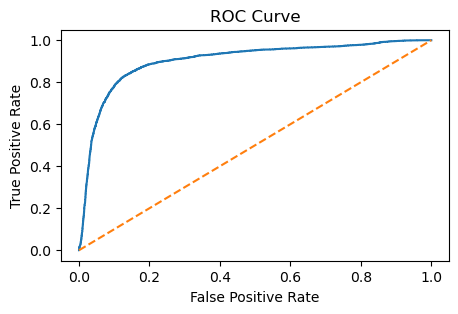

In [13]:
print("Accuracy")
print(accuracy_score(y_test,y_pred))
print()

print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))
print()

print("Classification Report")
print(classification_report(y_test,y_pred))
print()

print("AUC")
print(roc_auc_score(y_test,y_prob))

fpr,tpr,threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(5,3))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title ("ROC Curve")
plt.show()

## Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100,random_state=42)
forest.fit(x_train_forest,y_train)

forest_pred = forest.predict(x_test_forest)
forest_prob = forest.predict_proba(x_test_forest)[:,1]

In [15]:
#Checking the model performance

print("Accuracy")
print(accuracy_score(y_test,forest_pred))
print()

print("Confusion Matrix")
print(confusion_matrix(y_test,forest_pred))
print()

print("Classification Report")
print(classification_report(y_test,forest_pred))
print()

print("AUC")
print(roc_auc_score(y_test,forest_prob))

Accuracy
0.9447663433681824

Confusion Matrix
[[11976   356]
 [  521  3025]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     12332
           1       0.89      0.85      0.87      3546

    accuracy                           0.94     15878
   macro avg       0.93      0.91      0.92     15878
weighted avg       0.94      0.94      0.94     15878


AUC
0.9735561227728649


## Comparing the two models

In [18]:
result = pd.DataFrame({"Model":["Logistic Regression", "Random Forest"],
                       "Accuracy": [accuracy_score(y_test,y_pred),accuracy_score(y_test,forest_pred)],
                        "AUC": [roc_auc_score(y_test,y_prob),roc_auc_score(y_test,forest_prob)]})
result

,Model,Accuracy,AUC
0,Logistic Regression,0.872969,0.902429
1,Random Forest,0.944766,0.973556


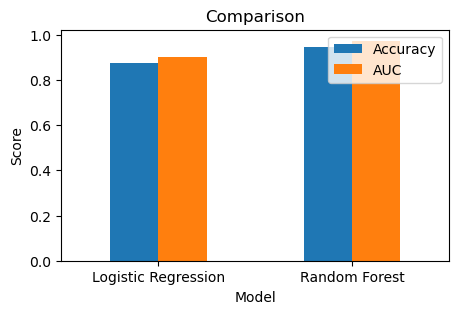

In [19]:
result.plot( x="Model", y= ["Accuracy","AUC"], kind="bar", figsize=(5,3))

plt.ylabel("Score")
plt.title("Comparison")
plt.xticks(rotation=0)
plt.show()

In [ ]:
## Conclusion

#In this project, machine learning techniques were used in order to predict loan defaults using SBA loan data.
#The data was loaded and cleaned. The Logistic Regression and Random Forest models were trained.
#The Logistic Regression model got an accuracy of 87.3% with an AUC of 0.902
#The Random Forest model performed better with an accuracy of 94.5% and an AUC of 0.974
#Overall the Random Forest model was better at predicting loan defaults with the highest overall performance.